In [44]:
%matplotlib inline
from matplotlib import pyplot as plt
import numpy as np
import torch

torch.set_printoptions(edgeitems=2, linewidth=75)
torch.manual_seed(123)
from torchvision import datasets
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from collections import OrderedDict

In [3]:
conv = nn.Conv2d(3, 16, kernel_size=3) # 3 input channels (RGB), 16 output channels, 3x3 square convolution kernel
print(conv.weight.shape, conv.bias.shape) # torch.Size([16, 3, 3, 3]) torch.Size([16])
conv

torch.Size([16, 3, 3, 3]) torch.Size([16])


Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))

In [5]:
data_path = '../data-unversioned/p1ch7/'


transformed_cifar10 = datasets.CIFAR10(
    data_path, train=True, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ])) # Apply ToTensor and Normalize transforms to dataset

transformed_cifar10_val = datasets.CIFAR10(
    data_path, train=False, download=False,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.4915, 0.4823, 0.4468),
                             (0.2470, 0.2435, 0.2616))
    ])) # Apply ToTensor and Normalize transforms to validation dataset

In [6]:
label_map = {0: 0, 2: 1} # Map original labels to new labels
class_names = ['airplane', 'bird'] # New class names
cifar2 = [(img, label_map[label])
          for img, label in transformed_cifar10
          if label in [0, 2]] # Filter and relabel the dataset
print(len(cifar2))
cifar2_val = [(img, label_map[label])
              for img, label in transformed_cifar10_val
              if label in [0, 2]] # Filter and relabel the validation dataset
print(len(cifar2_val))

10000
2000


In [17]:
img, _ = cifar2[1] # Get the first image and label from the dataset
output = conv(img.unsqueeze(0)) # Apply convolutional layer to the image
img.unsqueeze(0).shape, output.shape # (torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

(torch.Size([1, 3, 32, 32]), torch.Size([1, 16, 30, 30]))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9806982..1.9497813].


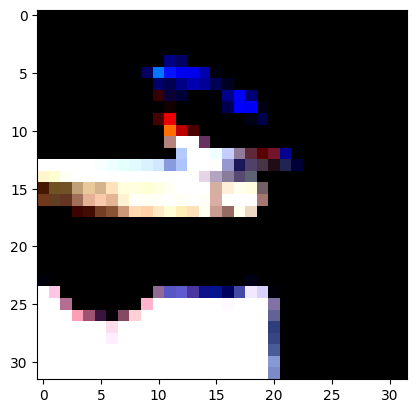

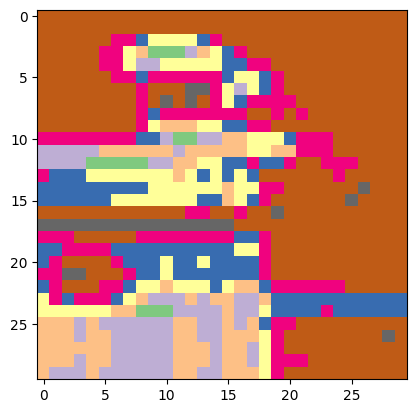

In [18]:
# display the img and the first channel of the output
plt.imshow(img.permute(1, 2, 0).detach()) # Display the original image
plt.show()

plt.imshow(output[0, 0].detach(), cmap='Accent') # Display the first channel of the output
plt.show()

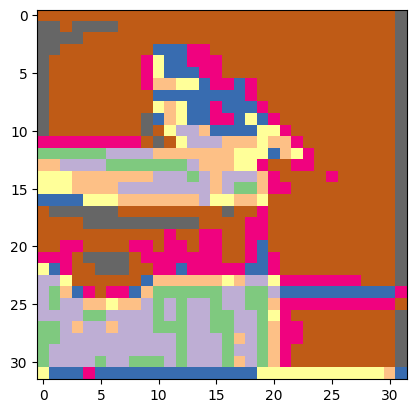

In [20]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1) # 3 input channels (RGB), 1 output channel, 3x3 square convolution kernel with padding
output = conv(img.unsqueeze(0)) # Apply convolutional layer to the image
img.unsqueeze(0).shape, output.shape # (torch.Size([1, 3, 32, 32]), torch.Size([1, 1, 32, 32]))

# padding is needed to maintain the original image size after convolution. Without padding, the output size is reduced due to the convolution operation.
plt.imshow(output[0, 0].detach(), cmap='Accent') # Display the output

In [21]:
with torch.no_grad():
    conv.bias.zero_()

with torch.no_grad():
    conv.weight.fill_(1.0 / 9.0)


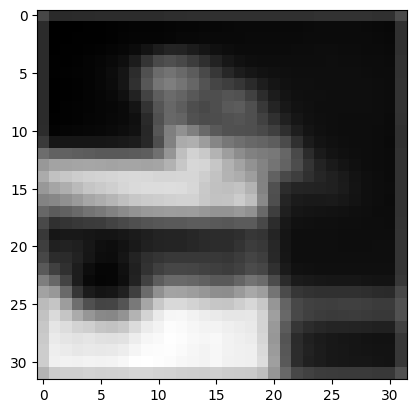

In [22]:
output = conv(img.unsqueeze(0))
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.show()

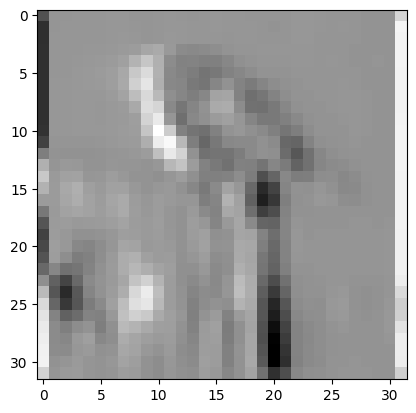

In [ ]:
conv = nn.Conv2d(3, 1, kernel_size=3, padding=1) # 3 input channels (RGB), 1 output channel, 3x3 square convolution kernel with padding

with torch.no_grad(): # set custom edge detection kernel
    conv.weight[:] = torch.tensor([[-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0],
                                   [-1.0, 0.0, 1.0]]) # reshape to (1, 3, 3, 3)
    conv.bias.zero_() # zero bias


output = conv(img.unsqueeze(0)) # Apply convolutional layer to the image
plt.imshow(output[0, 0].detach(), cmap='gray')
plt.show()

In [24]:
pool = nn.MaxPool2d(2) # 2x2 max pooling
output = pool(img.unsqueeze(0)) # Apply max pooling to the image

print(img.unsqueeze(0).shape, output.shape)

torch.Size([1, 3, 32, 32]) torch.Size([1, 3, 16, 16])


In [25]:
model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), # input channels, output channels, kernel size
            nn.Tanh(), # activation function
            nn.MaxPool2d(2), # pooling layer with kernel size 2
            nn.Conv2d(16, 8, kernel_size=3, padding=1), # input channels, output channels, kernel size
            nn.Tanh(), # activation function
            nn.MaxPool2d(2), # pooling layer with kernel size 2
            # ...
            )

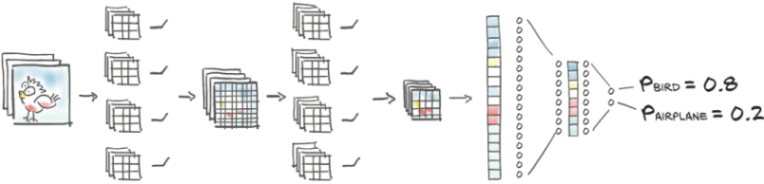

Shape of a typical convolutional network, including the one we’re building. An image is fed to a series of convolutions and max pooling modules and then straightened into a 1D vector and fed into fully connected modules.

In [53]:
model = nn.Sequential(OrderedDict([
            ('conv1', nn.Conv2d(3, 16, kernel_size=3, padding=1)),
            ('tanh1', nn.Tanh()),
            ('pool1', nn.MaxPool2d(2)),
            ('conv2', nn.Conv2d(16, 8, kernel_size=3, padding=1)),
            ('tanh2', nn.Tanh()),
            ('pool2', nn.MaxPool2d(2)),
            ('flatten', nn.Flatten()),
            ('fc1', nn.Linear(8 * 8 * 8, 32)),
            ('tanh3', nn.Tanh()),
            ('fc2', nn.Linear(32, 2))
            ]))

In [47]:
model = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 8, kernel_size=3, padding=1),
            nn.Tanh(),
            nn.MaxPool2d(2),
            # ...                 
            nn.Linear(8 * 8 * 8, 32),
            nn.Tanh(),
            nn.Linear(32, 2))

numel_list = [[p.numel(),p.name] for p in model.parameters()]
#sum(numel_list)
numel_list

[[432, None],
 [16, None],
 [1152, None],
 [8, None],
 [16384, None],
 [32, None],
 [64, None],
 [2, None]]

In [54]:
for name, layer in model.named_modules():
    # skip the top-level container
    if name == "":
        continue
    
    # sum the number of parameters inside this layer
    params = sum(p.numel() for p in layer.parameters(recurse=False))
    print(f"{name}: {params} parameters")


conv1: 448 parameters
tanh1: 0 parameters
pool1: 0 parameters
conv2: 1160 parameters
tanh2: 0 parameters
pool2: 0 parameters
flatten: 0 parameters
fc1: 16416 parameters
tanh3: 0 parameters
fc2: 66 parameters


In [55]:
for name, param in model.named_parameters():
    print(f"{name}: {param.numel()} parameters")


conv1.weight: 432 parameters
conv1.bias: 16 parameters
conv2.weight: 1152 parameters
conv2.bias: 8 parameters
fc1.weight: 16384 parameters
fc1.bias: 32 parameters
fc2.weight: 64 parameters
fc2.bias: 2 parameters


In [56]:
from collections import defaultdict

layer_params = defaultdict(int)

for param_name, param in model.named_parameters():
    layer_name = param_name.split('.')[0]     # "0.weight" → "0"
    layer_params[layer_name] += param.numel()

for layer, count in layer_params.items():
    print(f"Layer {layer}: {count} parameters")


Layer conv1: 448 parameters
Layer conv2: 1160 parameters
Layer fc1: 16416 parameters
Layer fc2: 66 parameters


In [57]:
model(img.unsqueeze(0))

tensor([[0.0031, 0.0362]], grad_fn=<AddmmBackward0>)

In [58]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.act1 = nn.Tanh()
        self.pool1 = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.act2 = nn.Tanh()
        self.pool2 = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.act3 = nn.Tanh()
        self.fc2 = nn.Linear(32, 2)

    def forward(self, x):
        out = self.pool1(self.act1(self.conv1(x)))
        out = self.pool2(self.act2(self.conv2(out)))
        out = out.view(-1, 8 * 8 * 8) # this reshapes the tensor for the fully connected layer is eqivalent to nn.Flatten()
        out = self.act3(self.fc1(out))
        out = self.fc2(out)
        return out

In [62]:
model1 = Net()

sum([p.numel() for p in model1.parameters()])

18090

In [63]:
from collections import defaultdict

layer_params = defaultdict(int)

for param_name, param in model1.named_parameters():
    layer_name = param_name.split('.')[0]     # "0.weight" → "0"
    layer_params[layer_name] += param.numel()

for layer, count in layer_params.items():
    print(f"Layer {layer}: {count} parameters")


Layer conv1: 448 parameters
Layer conv2: 1160 parameters
Layer fc1: 16416 parameters
Layer fc2: 66 parameters


In [64]:
import torch.nn.functional as F
 
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)
 
    def forward(self, x):
        out = F.max_pool2d(torch.tanh(self.conv1(x)), 2)
        out = F.max_pool2d(torch.tanh(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out

In [65]:
model = Net()
model(img.unsqueeze(0))

tensor([[-0.0248,  0.0805]], grad_fn=<AddmmBackward0>)

In [66]:
import torch
import torch.nn as nn
import torch.nn.functional as F

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 8, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(8 * 8 * 8, 32)
        self.fc2 = nn.Linear(32, 2)
        
    def forward(self, x):
        out = F.max_pool2d(torch.relu(self.conv1(x)), 2)
        out = F.max_pool2d(torch.relu(self.conv2(out)), 2)
        out = out.view(-1, 8 * 8 * 8)
        out = torch.tanh(self.fc1(out))
        out = self.fc2(out)
        return out
    
model = Net()

learning_rate = 1e-2

optimizer = optim.SGD(model.parameters(), lr=learning_rate)

loss_fn = nn.CrossEntropyLoss()

n_epochs = 100

for epoch in range(n_epochs):
    for imgs, labels in train_loader:
        outputs = model(imgs)
        loss = loss_fn(outputs, labels)
                
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print("Epoch: %d, Loss: %f" % (epoch, float(loss)))

C:\Users\moidhassan\AppData\Local\Temp\ipykernel_52548\2599224242.py:43: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:836.)
  print("Epoch: %d, Loss: %f" % (epoch, float(loss)))


Epoch: 0, Loss: 0.402269
Epoch: 1, Loss: 0.489934
Epoch: 2, Loss: 0.503376
Epoch: 3, Loss: 0.291215
Epoch: 4, Loss: 0.430342
Epoch: 5, Loss: 0.540629
Epoch: 6, Loss: 0.339939
Epoch: 7, Loss: 0.422767
Epoch: 8, Loss: 0.350313
Epoch: 9, Loss: 0.322772
Epoch: 10, Loss: 0.364461
Epoch: 11, Loss: 0.337813
Epoch: 12, Loss: 0.226242
Epoch: 13, Loss: 0.532515
Epoch: 14, Loss: 0.418037
Epoch: 15, Loss: 0.569028
Epoch: 16, Loss: 0.134450
Epoch: 17, Loss: 0.283594
Epoch: 18, Loss: 0.261330
Epoch: 19, Loss: 0.567636
Epoch: 20, Loss: 0.347357
Epoch: 21, Loss: 0.359113
Epoch: 22, Loss: 0.291266
Epoch: 23, Loss: 0.211360
Epoch: 24, Loss: 0.338220
Epoch: 25, Loss: 0.164936
Epoch: 26, Loss: 0.200478
Epoch: 27, Loss: 0.118259
Epoch: 28, Loss: 0.261038
Epoch: 29, Loss: 0.256759
Epoch: 30, Loss: 0.440882
Epoch: 31, Loss: 0.297667
Epoch: 32, Loss: 0.095826
Epoch: 33, Loss: 0.379305
Epoch: 34, Loss: 0.162664
Epoch: 35, Loss: 0.316012
Epoch: 36, Loss: 0.261527
Epoch: 37, Loss: 0.227881
Epoch: 38, Loss: 0.244

In [ ]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)
        outputs = model(imgs)
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Accuracy Training: %f" % (correct / total))

val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)

correct = 0
total = 0

with torch.no_grad():
    for imgs, labels in val_loader:
        outputs = model(imgs)
        _, predicted = torch.max(outputs, dim=1)
        total += labels.shape[0]
        correct += int((predicted == labels).sum())
        
print("Validation Accuracy: %f" % (correct / total))

Accuracy Training: 0.946300
Validation Accuracy: 0.879500


In [71]:
import datetime                                                       

def training_loop(n_epochs, optimizer, model, loss_fn, train_loader): # training loop function
    for epoch in range(1, n_epochs + 1): # iterate over epochs
        loss_train = 0.0 # initialize training loss
        for imgs, labels in train_loader: # iterate over batches for inner loop

            imgs = imgs.to(device) # move images to device
            labels = labels.to(device) # move labels to device
 
            outputs = model(imgs) # forward pass
 
            loss = loss_fn(outputs, labels) # compute loss
 
            optimizer.zero_grad() # zero gradients
 
            loss.backward() # backward pass
 
            optimizer.step() # update weights
 
            loss_train += loss.item() # accumulate training loss
 
        if epoch == 1 or epoch % 10 == 0:
            print('{} Epoch {}, Training loss {}'.format(
                datetime.datetime.now(), epoch,
                loss_train / len(train_loader)))      

In [82]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=True)

model = Net().to(device)
n_epochs = 50
learning_rate = 1e-2
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
loss_fn = nn.CrossEntropyLoss()
training_loop(n_epochs, optimizer, model, loss_fn, train_loader)


Using device: cuda
2025-11-28 17:48:44.581804 Epoch 1, Training loss 0.5770596381585309
2025-11-28 17:48:48.420820 Epoch 10, Training loss 0.3274879670067198
2025-11-28 17:49:06.644520 Epoch 20, Training loss 0.29139557983844905
2025-11-28 17:49:26.548572 Epoch 30, Training loss 0.26427693541642205
2025-11-28 17:49:47.737955 Epoch 40, Training loss 0.24146941736055788
2025-11-28 17:50:00.600672 Epoch 50, Training loss 0.21818918858174305


In [84]:
train_loader = torch.utils.data.DataLoader(cifar2, batch_size=64,
                                           shuffle=False)
val_loader = torch.utils.data.DataLoader(cifar2_val, batch_size=64,
                                         shuffle=False)
 
def validate(model, train_loader, val_loader):
    for name, loader in [("train", train_loader), ("val", val_loader)]:
        correct = 0
        total = 0
 
        with torch.no_grad(): # no gradient calculation
            for imgs, labels in loader:
                imgs = imgs.to(device) # move images to device
                labels = labels.to(device) # move labels to device
                outputs = model(imgs) # forward pass
                _, predicted = torch.max(outputs, dim=1) # get predicted class
                total += labels.shape[0] # get total number of labels
                correct += int((predicted == labels).sum()) # count correct predictions
 
        print("Accuracy {}: {:.2f}".format(name , correct / total))
 
validate(model, train_loader, val_loader)

Accuracy train: 0.92
Accuracy val: 0.89


In [85]:
torch.save(model.state_dict(), data_path + 'birds_vs_airplanes.pt') # save model parameters

In [86]:
loaded_model = Net() # create a new instance of the model
loaded_model.load_state_dict(torch.load(data_path
                                        + 'birds_vs_airplanes.pt'))

<All keys matched successfully>